### Exploratly Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/Users/mdnazmulhudanabil/Desktop/Heart Disease Advance Projects/data/Heart Disease Dataset.csv")
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [4]:
df.columns

Index(['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
       'fasting blood sugar', 'resting ecg', 'max heart rate',
       'exercise angina', 'oldpeak', 'ST slope', 'target'],
      dtype='object')

In [5]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [6]:
df.isnull().sum()

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

<Axes: xlabel='target', ylabel='count'>

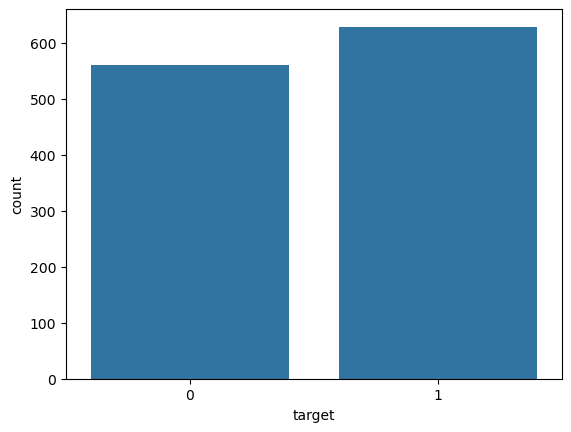

In [7]:
sns.countplot(x="target", data=df)

<Axes: xlabel='sex', ylabel='count'>

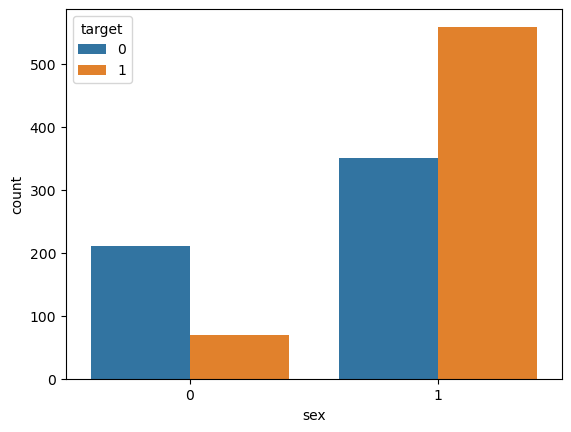

In [8]:
sns.countplot(x="sex", hue="target" ,data=df)

In [9]:
df["sex"].value_counts()

sex
1    909
0    281
Name: count, dtype: int64

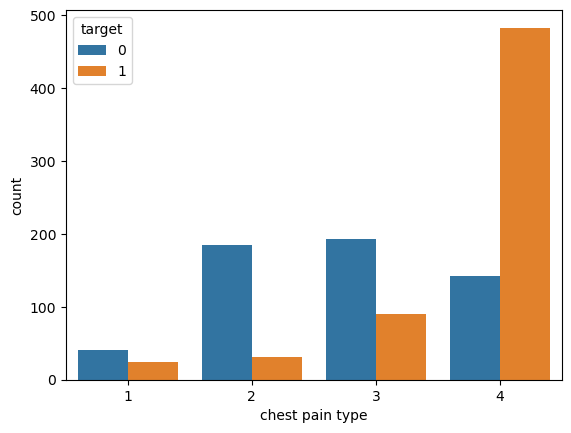

In [10]:
sns.countplot(x="chest pain type", hue="target", data=df)
plt.show()

<Axes: xlabel='fasting blood sugar', ylabel='count'>

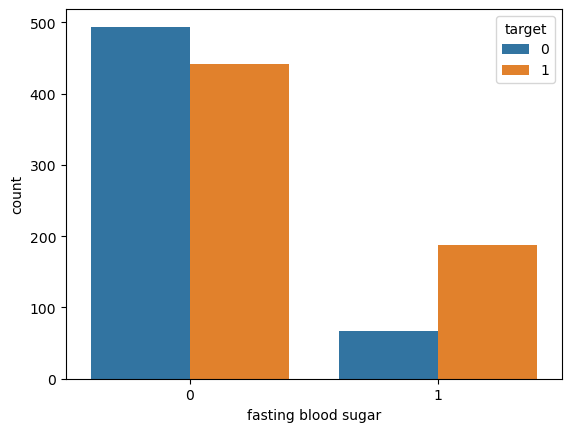

In [11]:
sns.countplot(x = 'fasting blood sugar', hue="target", data=df)

In [12]:
df.columns

Index(['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
       'fasting blood sugar', 'resting ecg', 'max heart rate',
       'exercise angina', 'oldpeak', 'ST slope', 'target'],
      dtype='object')

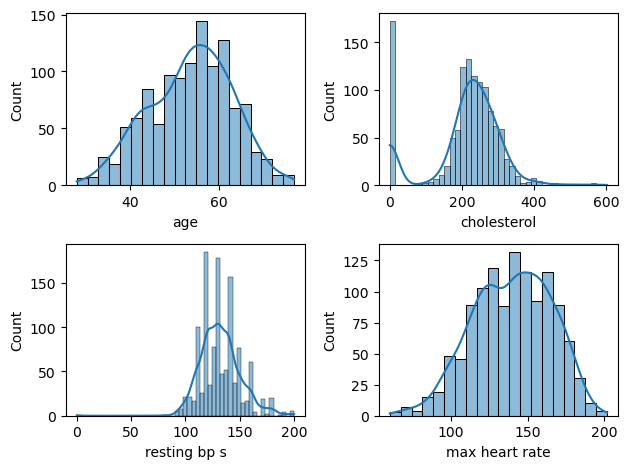

In [13]:
def plotting(val, num):
    plt.subplot(2, 2, num)
    sns.histplot(df[val], kde=True)

plotting("age", 1)
plotting("cholesterol", 2)
plotting("resting bp s", 3)
plotting("max heart rate", 4)
plt.tight_layout()

In [14]:
df["cholesterol"].value_counts()

cholesterol
0      172
254     16
234     13
211     13
204     13
      ... 
385      1
466      1
129      1
338      1
131      1
Name: count, Length: 222, dtype: int64

### Without 0 Cholesterol mean

In [15]:
chol_mean = df.loc[df["cholesterol"] != 0, "cholesterol"].mean()
chol_mean
df["cholesterol"] = df["cholesterol"].replace(0, chol_mean)
df["cholesterol"] = df["cholesterol"].round(2)

In [16]:
restingbp_mean = df.loc[df["resting bp s"] != 0, "cholesterol"].mean()
restingbp_mean
df["resting bp s"] = df["resting bp s"].replace(0, restingbp_mean)
df["resting bp s"] = df["resting bp s"].round(2)

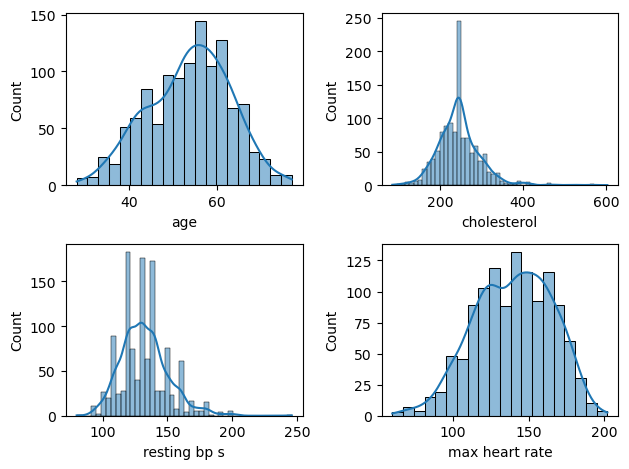

In [17]:
def plotting(val, num):
    plt.subplot(2, 2, num)
    sns.histplot(df[val], kde=True)

plotting("age", 1)
plotting("cholesterol", 2)
plotting("resting bp s", 3)
plotting("max heart rate", 4)
plt.tight_layout()

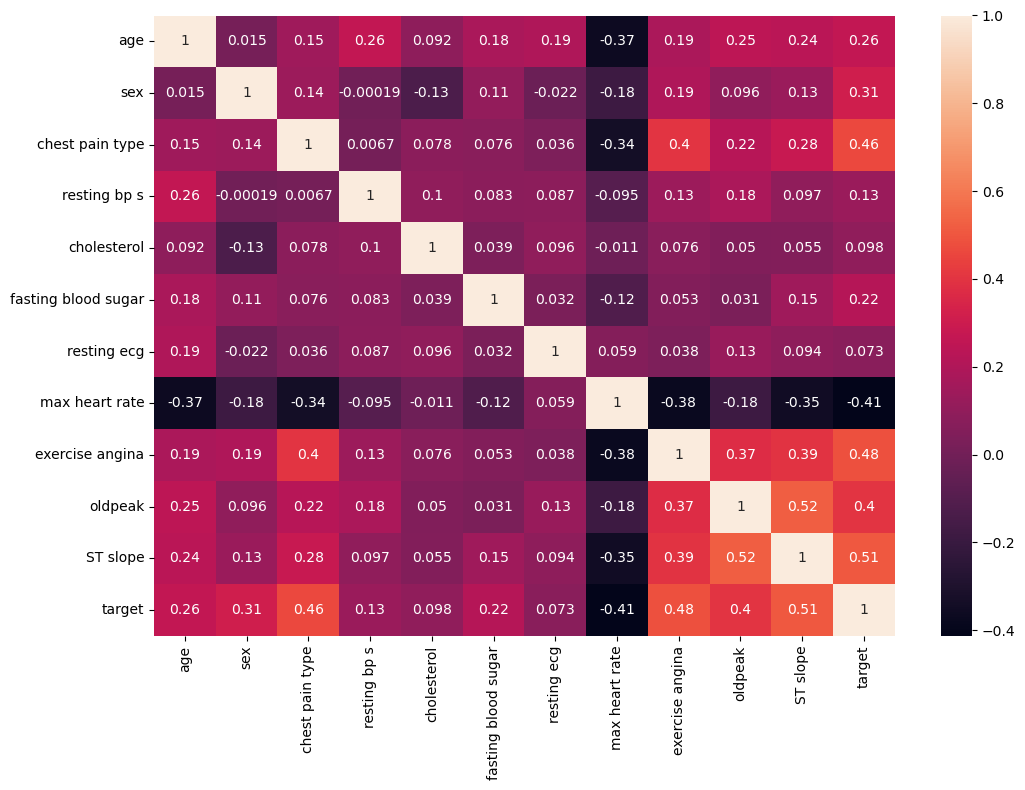

In [18]:
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.tight_layout()

### Data Preproccsing

In [19]:
# This are categorical columns
categorical_cols = [
    "sex",
    "chest pain type",
    "fasting blood sugar",
    "resting ecg",
    "exercise angina",
    "ST slope"
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded = df_encoded.astype(int)
df_encoded.head()

,age,resting bp s,cholesterol,max heart rate,oldpeak,target,sex_1,chest pain type_2,chest pain type_3,chest pain type_4,fasting blood sugar_1,resting ecg_1,resting ecg_2,exercise angina_1,ST slope_1,ST slope_2,ST slope_3
0,40,140,289,172,0,0,1,1,0,0,0,0,0,0,1,0,0
1,49,160,180,156,1,1,0,0,1,0,0,0,0,0,0,1,0
2,37,130,283,98,0,0,1,1,0,0,0,1,0,0,1,0,0
3,48,138,214,108,1,1,0,0,0,1,0,0,0,1,0,1,0
4,54,150,195,122,0,0,1,0,1,0,0,0,0,0,1,0,0


In [20]:
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140.0,289.0,0,0,172,0,0.0,1,0
1,49,0,3,160.0,180.0,0,0,156,0,1.0,2,1
2,37,1,2,130.0,283.0,0,1,98,0,0.0,1,0
3,48,0,4,138.0,214.0,0,0,108,1,1.5,2,1
4,54,1,3,150.0,195.0,0,0,122,0,0.0,1,0


In [21]:
# Neumeric Column Label Encode
from sklearn.preprocessing import StandardScaler

neumeric_col = ["age","resting bp s" , "oldpeak", "cholesterol", "max heart rate"]

scaler = StandardScaler()

df_encoded[neumeric_col] = scaler.fit_transform(df_encoded[neumeric_col])
df_encoded

,age,resting bp s,cholesterol,max heart rate,oldpeak,target,sex_1,chest pain type_2,chest pain type_3,chest pain type_4,fasting blood sugar_1,resting ecg_1,resting ecg_2,exercise angina_1,ST slope_1,ST slope_2,ST slope_3
0,-1.466728,0.418617,0.816769,1.265039,-0.726708,0,1,1,0,0,0,0,0,0,1,0,0
1,-0.504600,1.514425,-1.242898,0.637758,0.269585,1,0,0,1,0,0,0,0,0,0,1,0
2,-1.787437,-0.129287,0.703393,-1.636136,-0.726708,0,1,1,0,0,0,1,0,0,1,0,0
3,-0.611503,0.309036,-0.600433,-1.244085,0.269585,1,0,0,0,1,0,0,0,1,0,1,0
4,0.029915,0.966521,-0.959458,-0.695214,-0.726708,0,1,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1185,-0.932213,-1.225095,0.344368,-0.303164,0.269585,1,1,0,0,0,0,0,0,0,0,1,0
1186,1.526558,0.637779,-0.997250,0.049682,2.262172,1,1,0,0,1,1,0,0,0,0,1,0
1187,0.350624,-0.129287,-2.168804,-0.969650,0.269585,1,1,0,0,1,0,0,0,1,0,1,0
1188,0.350624,-0.129287,-0.184721,1.343449,-0.726708,1,0,1,0,0,0,0,1,0,0,1,0


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [23]:
X = df_encoded.drop("target", axis=1)
y = df_encoded["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
models = {
    "Logistic Regression":LogisticRegression(),
    "Navie Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN":KNeighborsClassifier(),
    "SVM":SVC(probability=True)
}

result = []

In [25]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    result.append({
        "model":name,
        "Accurecy:":round(acc, 4),
        "F1 Score:":round(f1, 4)
    })

In [26]:
result

[{'model': 'Logistic Regression', 'Accurecy:': 0.8529, 'F1 Score:': 0.8679},
 {'model': 'Navie Bayes', 'Accurecy:': 0.8445, 'F1 Score:': 0.8614},
 {'model': 'Decision Tree', 'Accurecy:': 0.8571, 'F1 Score:': 0.8672},
 {'model': 'KNN', 'Accurecy:': 0.8866, 'F1 Score:': 0.9004},
 {'model': 'SVM', 'Accurecy:': 0.895, 'F1 Score:': 0.9077}]

In [27]:
import joblib

joblib.dump(models["SVM"], 'svm_heart_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.to_list(), 'columns.pkl')

['columns.pkl']